**Capítulo 7**  
**7.4 Exemplo de aplicação de Random Forest para classificação**<br>
**7.7 Exemplo de aplicação de ADABOOST para classificação**<br>
**7.9 Aplicação de Gradient Boosting para classificação**<br>
**7.12 Aplicação de XGBoost a um problema de classificação**<br>
**Base TECAL.xlsx**

In [2]:
# Bibliotecas e funções necessárias
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.colors import LinearSegmentedColormap

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold

from sklearn.inspection import permutation_importance

from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone

from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay

from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay, log_loss, brier_score_loss

import warnings
warnings.filterwarnings('ignore')  # Oculta avisos para manter a saída mais limpa

In [3]:
# Carregar os dados
dados = pd.read_excel('TECAL.xlsx', sheet_name='TECAL')
dados = dados.iloc[:, 1:]  # Remove a coluna de identificação do cliente
dados.head()

,idade,linhas,temp_cli,renda,fatura,temp_rsd,local,tvcabo,debaut,cancel
0,51,3,26,5320,543,7.3,A,sim,nao,nao
1,36,2,16,5620,482,4.5,A,sim,nao,nao
2,35,1,15,4860,593,4.8,A,nao,nao,nao
3,44,1,16,5400,646,6.3,C,sim,sim,sim
4,40,1,22,6590,1184,6.2,C,sim,nao,nao


In [4]:
# As variáveis 'local', 'tvcabo', 'debaut' e 'cancel' são qualitativas (categóricas).
# Devemos convertê-las para variáveis numéricas antes de usá-las nos algoritmos vistos neste capítulo.
# Vamos primeiro marcar essas variáveis como 'category', o que ajuda na organização dos dados.

cat_cols = ['local', 'tvcabo', 'debaut', 'cancel']
for col in cat_cols:
    dados[col] = dados[col].astype('category')

# Verificamos os tipos das variáveis após a conversão
dados.dtypes

idade          int64
linhas         int64
temp_cli       int64
renda          int64
fatura         int64
temp_rsd     float64
local       category
tvcabo      category
debaut      category
cancel      category
dtype: object

In [6]:
# Agora vamos transformar as variáveis categóricas em variáveis numéricas (one-hot encoding).

dados_encoded = pd.get_dummies(dados, drop_first=True)

# Visualizamos o resultado
dados_encoded.head()

,idade,linhas,temp_cli,renda,fatura,temp_rsd,local_B,local_C,local_D,tvcabo_sim,debaut_sim,cancel_sim
0,51,3,26,5320,543,7.3,False,False,False,True,False,False
1,36,2,16,5620,482,4.5,False,False,False,True,False,False
2,35,1,15,4860,593,4.8,False,False,False,False,False,False
3,44,1,16,5400,646,6.3,False,True,False,True,True,True
4,40,1,22,6590,1184,6.2,False,True,False,True,False,False


In [10]:
# A variável-alvo é 'cancel_sim', que representa se o cliente cancelou (1) ou não (0).
# Primeiro, vamos criar essa variável binária a partir da coluna original 'cancel'.

dados_encoded['cancel_sim'] = dados['cancel'].map({'sim': 1, 'nao': 0})

# Agora separamos as variáveis independentes (X) da variável dependente (y)
X = dados_encoded.drop(columns='cancel_sim')  # todas as variáveis preditoras
y = dados_encoded['cancel_sim']               # variável-alvo

# Dividimos em treino e teste (60% treino, 40% teste), estratificando a amostra

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=123
)

# Verificamos o tamanho das amostras
print(f'Treinamento: {X_train.shape[0]} observações')
print(f'Teste: {X_test.shape[0]} observações')

Treinamento: 1200 observações
Teste: 800 observações


In [12]:
# Para ajuste automático de hiperparâmetros com GridSearchCV

# Definir o modelo base
modelo_base = RandomForestClassifier(random_state=123)

# Definir grade de hiperparâmetros a testar
param_grid = {
    'n_estimators': [50, 100, 200],        # número de árvores
    'max_depth': [None, 5, 10],            # profundidade máxima
    'min_samples_split': [2, 5],           # mínimo de observações para split
    'min_samples_leaf': [1, 2],            # mínimo de observações em folha
    'max_features': ['sqrt', 'log2'],      # número de variáveis por divisão
    'oob_score': [True]
}

# Configurar a busca com validação cruzada
grid = GridSearchCV(estimator=modelo_base,
                    param_grid=param_grid,
                    scoring='neg_log_loss',
                    cv=5,
                    n_jobs=-1,
                    verbose=1)

# Ajustar nos dados de treino
grid.fit(X_train, y_train)

# Exibir os melhores parâmetros e log-loss em CV
print("Melhores hiperparâmetros encontrados:")
print(grid.best_params_)
print(f"Log-loss médio em CV: {-grid.best_score_:.6f}")

# Construir tabela com todos os resultados
resultados_grid = pd.DataFrame(grid.cv_results_)
resultados_grid['log_loss_cv'] = -resultados_grid['mean_test_score']
tabela_resultados = resultados_grid[['params', 'log_loss_cv', 'rank_test_score', 'mean_fit_time']] \
                                    .sort_values('log_loss_cv', ascending=True)

# Exibir os 5 melhores
print("\nTop 5 combinações de hiperparâmetros:")
display(tabela_resultados.head())

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Melhores hiperparâmetros encontrados:
{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100, 'oob_score': True}
Log-loss médio em CV: 0.406422

Top 5 combinações de hiperparâmetros:


,params,log_loss_cv,rank_test_score,mean_fit_time
49,"{'max_depth': 10, 'max_features': 'sqrt', 'min...",0.406422,1,1.611336
61,"{'max_depth': 10, 'max_features': 'log2', 'min...",0.406422,1,1.642529
50,"{'max_depth': 10, 'max_features': 'sqrt', 'min...",0.407084,3,3.312559
62,"{'max_depth': 10, 'max_features': 'log2', 'min...",0.407084,3,3.222231
20,"{'max_depth': None, 'max_features': 'log2', 'm...",0.407323,5,3.231529


,Variável,Importância
4,fatura,0.239291
2,temp_cli,0.167401
3,renda,0.132502
0,idade,0.123397
5,temp_rsd,0.117373
6,local_B,0.087179
8,local_D,0.034577
1,linhas,0.029973
7,local_C,0.026325
10,debaut_sim,0.024437


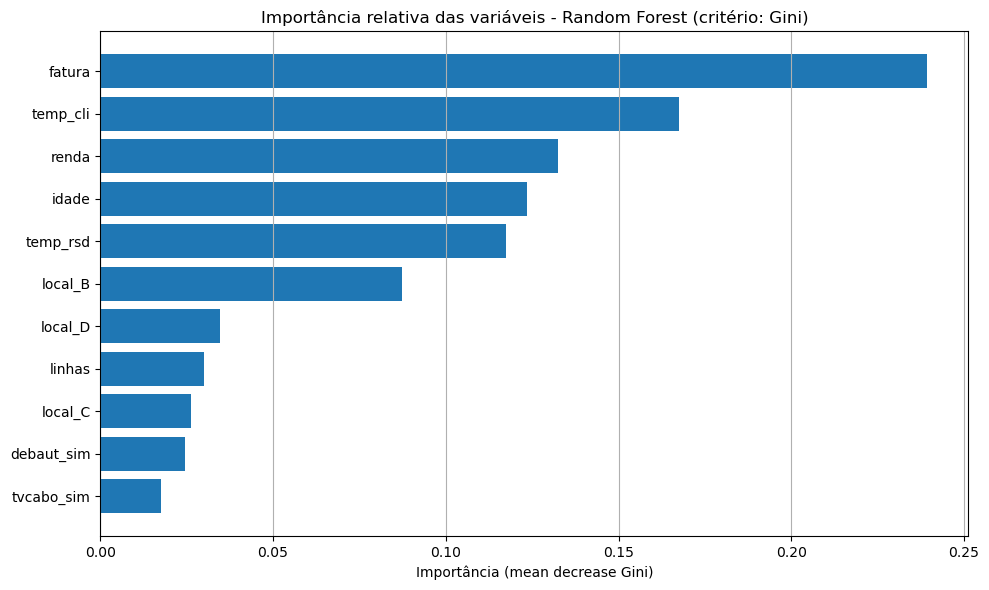

,Variável,MDA (Δ Acurácia média),Desvio-padrão
4,fatura,0.144472,0.006366
2,temp_cli,0.122167,0.007302
6,local_B,0.084028,0.005681
0,idade,0.068833,0.004263
5,temp_rsd,0.044000,0.003772
3,renda,0.043667,0.003513
8,local_D,0.041778,0.003048
7,local_C,0.027389,0.003507
1,linhas,0.018194,0.002781
10,debaut_sim,0.017083,0.002507


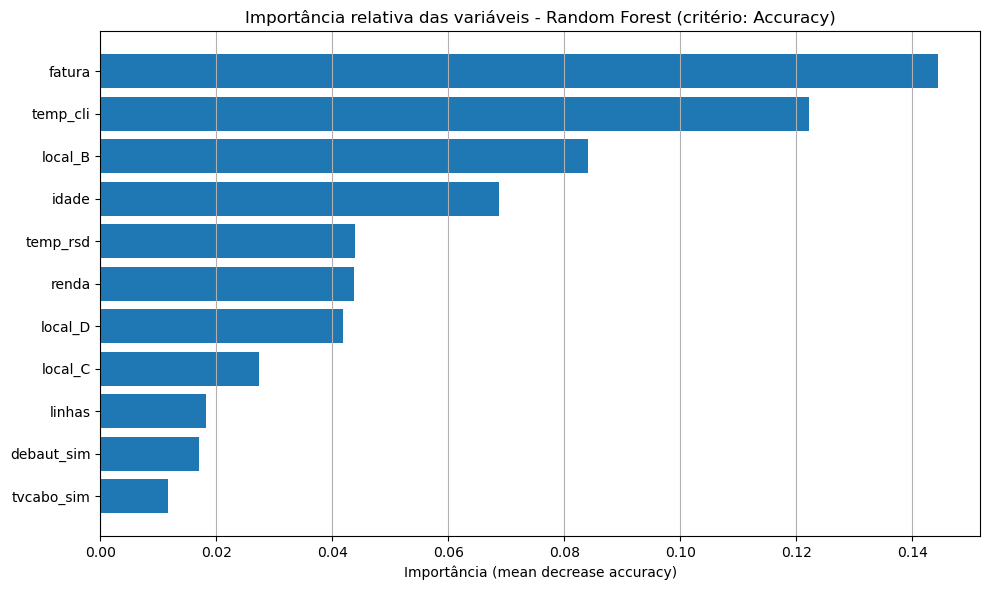

In [13]:
# Importância das variáveis no modelo final

# Modelo com melhores hiperparâmetros
modelo_rf = RandomForestClassifier(**grid.best_params_, random_state=123)

modelo_rf.fit(X_train, y_train)

importances = modelo_rf.feature_importances_

# Criar DataFrame ordenado
importancia_df = pd.DataFrame({
    'Variável': X.columns,
    'Importância': importances
}).sort_values(by='Importância', ascending=False)

# Visualizar tabela
display(importancia_df)

# Gráfico de barras
plt.figure(figsize=(10,6))
plt.barh(importancia_df['Variável'], importancia_df['Importância'])
plt.xlabel("Importância (mean decrease Gini)")
plt.title("Importância relativa das variáveis - Random Forest (critério: Gini)")
plt.gca().invert_yaxis()
plt.grid(axis='x')
plt.tight_layout()
plt.show()

# Importância por permutação (Mean Decrease Accuracy - MDA)
# Calcula MDA no teste (queda média de acurácia ao permutar cada variável)
perm = permutation_importance(
    modelo_rf,
    X_train, y_train,
    scoring="accuracy",
    n_repeats=30,
    random_state=123,
    n_jobs=-1
)

# Organiza em DataFrame
mda_df = pd.DataFrame({
    "Variável": X_train.columns,
    "MDA (Δ Acurácia média)": perm.importances_mean,
    "Desvio-padrão": perm.importances_std
}).sort_values(by="MDA (Δ Acurácia média)", ascending=False)

# Visualiza a tabela
display(mda_df)

# Gráfico de barras (com erro-padrão)
plt.figure(figsize=(10, 6))
plt.barh(
    mda_df["Variável"],
    mda_df["MDA (Δ Acurácia média)"]
)
plt.xlabel("Importância (mean decrease accuracy)")
plt.title("Importância relativa das variáveis - Random Forest (critério: Accuracy)")
plt.gca().invert_yaxis()
plt.grid(axis="x")
plt.tight_layout()
plt.show()

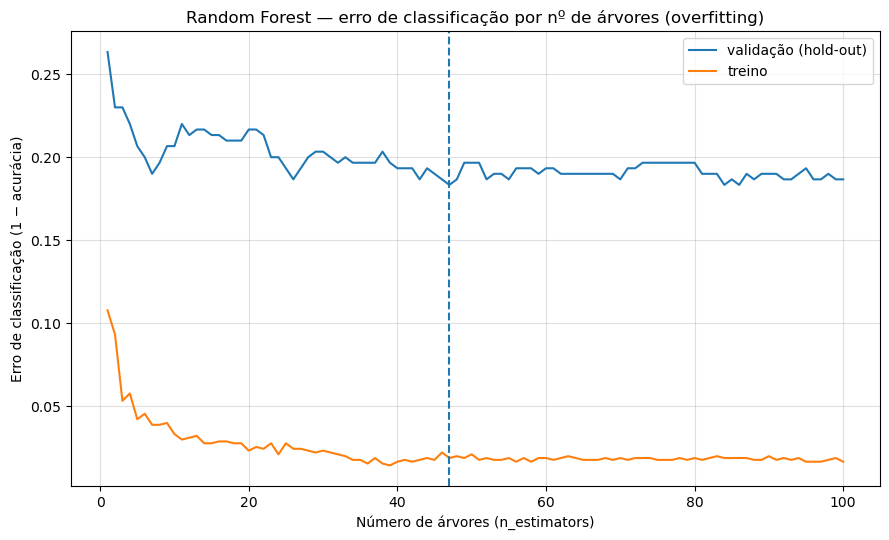

Melhor nº de árvores (menor erro no hold-out): 47 de 100


In [14]:
# Evolução dos erros (treino vs. hold-out) - Random Forest

from sklearn.model_selection import StratifiedShuffleSplit

# Hiperparâmetros vindos do GridSearchCV de RF
best = grid.best_params_.copy()
N_EST = int(best.get('n_estimators', 100))
best['n_estimators'] = N_EST

# Split hold-out dentro do treino
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.25, random_state=123)
(tr_idx, va_idx), = sss.split(X_train, y_train)
X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]

rf_kwargs = {k: v for k, v in best.items() if k != 'n_estimators'}

rf = RandomForestClassifier(random_state=123, warm_start=True, **rf_kwargs)

train_err, val_err = [], []
for n in range(1, N_EST + 1):
    rf.set_params(n_estimators=n)
    rf.fit(X_tr, y_tr)

    y_pred_tr = rf.predict(X_tr)
    y_pred_va = rf.predict(X_va)

    train_err.append(1.0 - accuracy_score(y_tr, y_pred_tr))
    val_err.append(1.0 - accuracy_score(y_va, y_pred_va))

train_err = np.asarray(train_err)
val_err   = np.asarray(val_err)
iters     = np.arange(1, len(train_err) + 1)
best_iter = int(np.argmin(val_err) + 1)

plt.figure(figsize=(9, 5.5))
plt.plot(iters, val_err, label="validação (hold-out)")
plt.plot(iters, train_err, label="treino")
plt.axvline(best_iter, linestyle="--")
plt.title("Random Forest — erro de classificação por nº de árvores (overfitting)")
plt.xlabel("Número de árvores (n_estimators)")
plt.ylabel("Erro de classificação (1 − acurácia)")
plt.legend(loc="best")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print(f"Melhor nº de árvores (menor erro no hold-out): {best_iter} de {N_EST}")

In [18]:
# Reajustando o modelo com {best_iter} iterações:

rf_params = grid.best_params_.copy()
rf_params['n_estimators'] = int(best_iter)

modelo_rf_final = RandomForestClassifier(random_state=123, **rf_params)

modelo_rf_final.fit(X_train, y_train)

print("Parâmetros finais:", rf_params)

Parâmetros finais: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 47, 'oob_score': True}


Acurácia no conjunto de teste: 82.25%


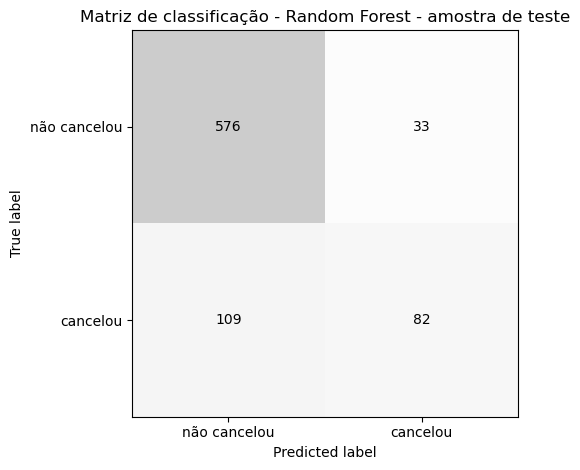

AUROC no conjunto de teste: 0.8436
Log-loss no conjunto de teste: 0.398358


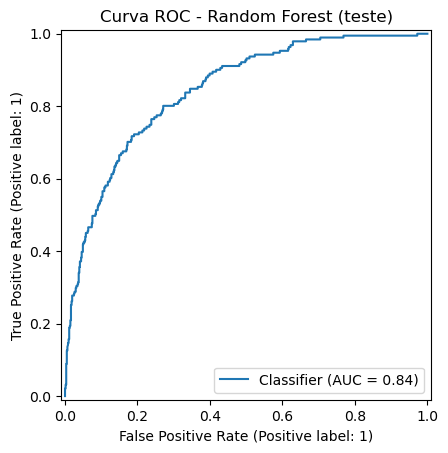

In [20]:
# Estimar probabilidades no conjunto de teste e calcular métricas de performance

# Probabilidades no conjunto de teste
probs_test_rf = modelo_rf_final.predict_proba(X_test)[:, 1]

# Classificação
y_pred_rf = modelo_rf_final.predict(X_test)

# Calcular acurácia
acuracia_teste_rf = accuracy_score(y_test, y_pred_rf)
print(f"Acurácia no conjunto de teste: {acuracia_teste_rf:.2%}")

# Matriz de classificação
matriz_classificacao_rf = confusion_matrix(y_test, y_pred_rf)

# Exibir matriz
light_greys = LinearSegmentedColormap.from_list(
    "light_greys", ["#FFFFFF", "#F2F2F2", "#E5E5E5", "#D9D9D9", "#CCCCCC"]
)

disp = ConfusionMatrixDisplay(confusion_matrix=matriz_classificacao_rf,
                              display_labels=["não cancelou", "cancelou"])

disp.plot(cmap=light_greys, colorbar=False,
          im_kw={"vmin": 0, "vmax": matriz_classificacao_rf.max()})
for t in disp.text_.ravel():
    t.set_color("black")

plt.title(f"Matriz de classificação - Random Forest - amostra de teste")
plt.tight_layout()
plt.show()

# AUROC no conjunto de teste
auroc_rf = roc_auc_score(y_test, probs_test_rf)
print(f"AUROC no conjunto de teste: {auroc_rf:.4f}")

logloss_rf = log_loss(y_test, probs_test_rf)
print(f"Log-loss no conjunto de teste: {logloss_rf:.6f}")

# Curva ROC usando as probabilidades já calculadas
RocCurveDisplay.from_predictions(y_test, probs_test_rf)
plt.title("Curva ROC - Random Forest (teste)")
plt.show()

**Capítulo 7**  
**7.7 Exemplo de aplicação de ADABOOST para classificação**<br>
**Base TECAL.xlsx**

In [23]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedShuffleSplit

In [25]:
# Definindo o modelo base de AdaBoost (árvore fraca como base)

modelo_base = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(random_state=123),
    random_state=123
)

# Grade de hiperparâmetros a ser testada (AdaBoost + árvore fraca)
param_grid = {
    'n_estimators': [500, 1000],
    'learning_rate': [0.01, 0.05],
    'estimator__max_depth': [1, 3],
    'estimator__min_samples_split': [2, 5],
    'estimator__min_samples_leaf': [1, 3],
    'algorithm': ['SAMME']
}

grid = GridSearchCV(
    estimator=modelo_base,
    param_grid=param_grid,
    scoring='neg_log_loss',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=123),
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

# Exibir os melhores hiperparâmetros e log-loss em CV
print("Melhores hiperparâmetros encontrados:")
print(grid.best_params_)
print(f"Log-loss médio em validação cruzada: {-grid.best_score_:.6f}")

# Construir tabela com os resultados
resultados_grid_ada = pd.DataFrame(grid.cv_results_)
resultados_grid_ada['log_loss_cv'] = -resultados_grid_ada['mean_test_score']
tabela_resultados_ada = resultados_grid_ada[['params', 'log_loss_cv', 'rank_test_score', 'mean_fit_time']] \
                                    .sort_values('log_loss_cv', ascending=True)

print("\nTop 5 combinações de hiperparâmetros:")
display(tabela_resultados_ada.head())

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Melhores hiperparâmetros encontrados:
{'algorithm': 'SAMME', 'estimator__max_depth': 3, 'estimator__min_samples_leaf': 3, 'estimator__min_samples_split': 2, 'learning_rate': 0.01, 'n_estimators': 500}
Log-loss médio em validação cruzada: 0.434403

Top 5 combinações de hiperparâmetros:


,params,log_loss_cv,rank_test_score,mean_fit_time
24,"{'algorithm': 'SAMME', 'estimator__max_depth':...",0.434403,1,9.321537
28,"{'algorithm': 'SAMME', 'estimator__max_depth':...",0.434403,1,8.774203
20,"{'algorithm': 'SAMME', 'estimator__max_depth':...",0.434917,3,9.364805
16,"{'algorithm': 'SAMME', 'estimator__max_depth':...",0.434917,3,9.279854
29,"{'algorithm': 'SAMME', 'estimator__max_depth':...",0.448587,5,15.564699


Variáveis mais importantes no modelo:


,Variável,Importância
4,fatura,0.400414
2,temp_cli,0.375559
6,local_B,0.099408
7,local_C,0.034605
5,temp_rsd,0.031031
8,local_D,0.023435
3,renda,0.019307
0,idade,0.016242
1,linhas,0.000000
9,tvcabo_sim,0.000000


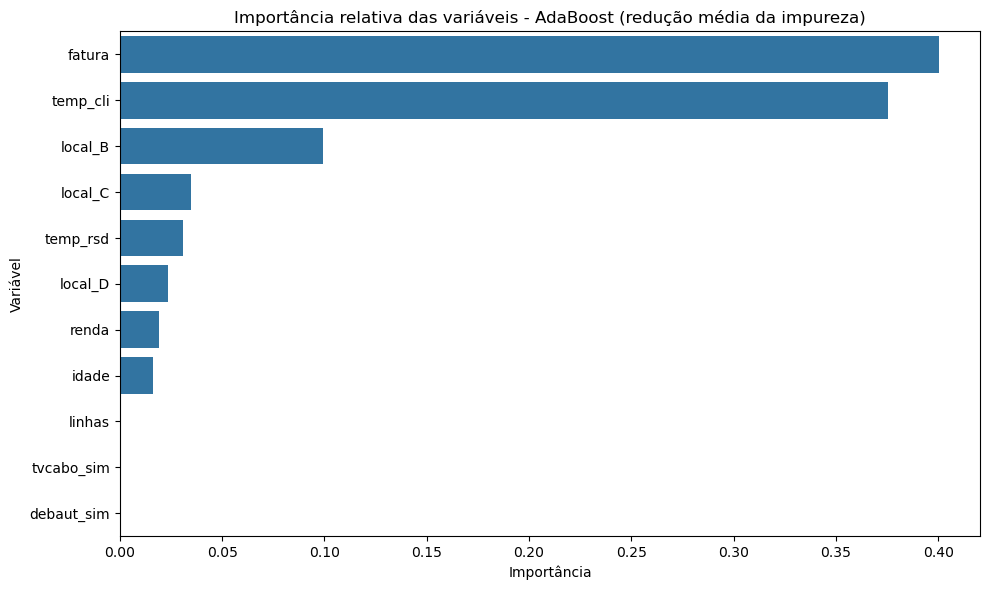

,Variável,MDA (Δ Acurácia média),Desvio-padrão
4,fatura,0.076889,0.008910
2,temp_cli,0.055639,0.007001
6,local_B,0.047194,0.005617
8,local_D,0.010806,0.002977
7,local_C,0.002333,0.002648
0,idade,0.002167,0.002059
3,renda,0.000861,0.000402
1,linhas,0.000000,0.000000
9,tvcabo_sim,0.000000,0.000000
10,debaut_sim,0.000000,0.000000


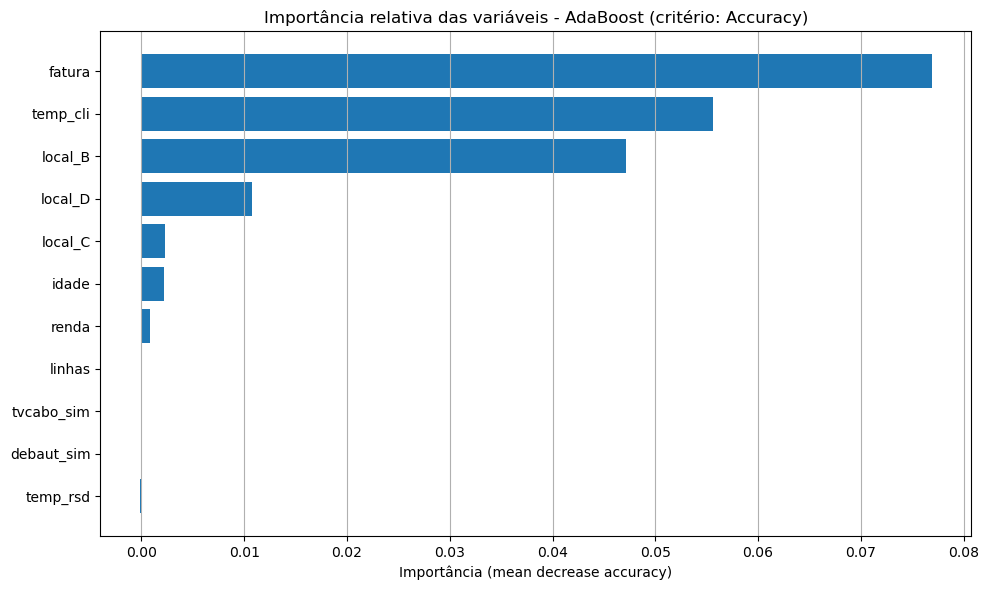

In [26]:
# Cálculo e visualização da importância relativa das variáveis

# Modelo com melhores hiperparâmetros
# Extrair parâmetros para AdaBoostClassifier e DecisionTreeClassifier
best_params = grid.best_params_.copy()
dt_params = {}
for key in list(best_params.keys()):
    if key.startswith('estimator__'):
        dt_params[key.split('__', 1)[1]] = best_params.pop(key)

modelo_ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(random_state=123, **dt_params),
    random_state=123,
    **best_params
)

modelo_ada.fit(X_train, y_train)

importancias = modelo_ada.feature_importances_

df_importancia = pd.DataFrame({'Variável': X_train.columns, 'Importância': importancias}) \
                   .sort_values(by='Importância', ascending=False)

print("Variáveis mais importantes no modelo:")
display(df_importancia.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(data=df_importancia.head(15), x='Importância', y='Variável')
plt.title('Importância relativa das variáveis - AdaBoost (redução média da impureza)')
plt.xlabel('Importância')
plt.ylabel('Variável')
plt.tight_layout()
plt.show()

# Importância por permutação (Mean Decrease Accuracy - MDA)
perm = permutation_importance(
    modelo_ada,
    X_train, y_train,
    scoring="accuracy",
    n_repeats=30,
    random_state=123,
    n_jobs=-1
)

# Organiza em DataFrame
mda_df_ada = pd.DataFrame({
    "Variável": X_train.columns,
    "MDA (Δ Acurácia média)": perm.importances_mean,
    "Desvio-padrão": perm.importances_std
}).sort_values(by="MDA (Δ Acurácia média)", ascending=False)

# Visualiza a tabela
display(mda_df_ada)

# Gráfico de barras (com erro-padrão)
plt.figure(figsize=(10, 6))
plt.barh(
    mda_df_ada["Variável"],
    mda_df_ada["MDA (Δ Acurácia média)"]
)
plt.xlabel("Importância (mean decrease accuracy)")
plt.title("Importância relativa das variáveis - AdaBoost (critério: Accuracy)")
plt.gca().invert_yaxis()
plt.grid(axis="x")
plt.tight_layout()
plt.show()

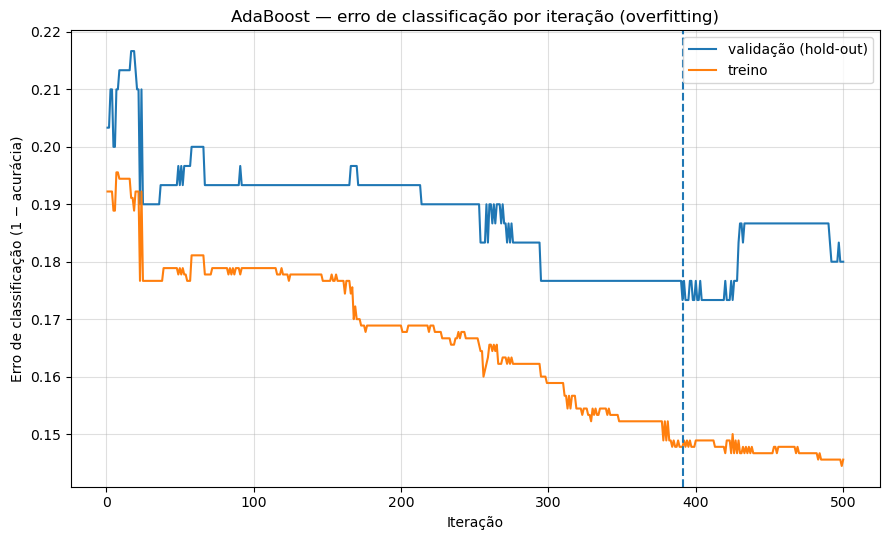

Melhor iteração (menor erro no hold-out): 391 de 500


In [27]:
# Evolução dos erros (treino vs. hold-out) - Adaboost

best = grid.best_params_.copy()
N_EST = best.get('n_estimators', 100)
best['n_estimators'] = N_EST

# Hiperparâmetros da árvore fraca (DecisionTree) vindos como estimator__*
dt_kwargs = locals().get('dt_kwargs', {})
if not dt_kwargs:
    dt_kwargs = {}
    for k, v in list(best.items()):
        if k.startswith('estimator__'):
            dt_kwargs[k.split('__', 1)[1]] = v
            best.pop(k)

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.25, random_state=123)
(tr_idx, va_idx), = sss.split(X_train, y_train)
X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]

dt = DecisionTreeClassifier(random_state=123, **dt_kwargs)
best = {k: v for k, v in best.items() if not k.startswith("estimator__")}
ada = AdaBoostClassifier(estimator=dt, random_state=123, **best)
ada.fit(X_tr, y_tr)

train_err, val_err = [], []
for y_pred_tr, y_pred_va in zip(ada.staged_predict(X_tr), ada.staged_predict(X_va)):
    train_err.append(1.0 - accuracy_score(y_tr, y_pred_tr))
    val_err.append(1.0 - accuracy_score(y_va, y_pred_va))

train_err = np.asarray(train_err)
val_err = np.asarray(val_err)
iters = np.arange(1, len(train_err) + 1)
best_iter = int(np.argmin(val_err) + 1)

plt.figure(figsize=(9, 5.5))
plt.plot(iters, val_err, label="validação (hold-out)")
plt.plot(iters, train_err, label="treino")
plt.axvline(best_iter, linestyle="--")
plt.title("AdaBoost — erro de classificação por iteração (overfitting)")
plt.xlabel("Iteração")
plt.ylabel("Erro de classificação (1 − acurácia)")
plt.legend(loc="best")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print(f"Melhor iteração (menor erro no hold-out): {best_iter} de {N_EST}")

In [28]:
# Reajustando o modelo com {best_iter} iterações:

best = grid.best_params_.copy()
best['n_estimators'] = best_iter
best.pop('random_state', None)

dt_kwargs = {}
for k, v in list(best.items()):
    if k.startswith('estimator__'):
        dt_kwargs[k.split('__', 1)[1]] = v
        best.pop(k)

dt = DecisionTreeClassifier(random_state=123, **dt_kwargs)
adaboost_best_iter = AdaBoostClassifier(estimator=dt, random_state=123, **best)

In [29]:
# Calibração do modelo (usando cross-validation)

from sklearn.calibration import CalibratedClassifierCV

# AdaBoost com os hiperparâmetros escolhidos
base = adaboost_best_iter

# Calibração com Platt (sigmoid) via CV 
platt_cv = CalibratedClassifierCV(estimator=base, method="sigmoid", cv=5)
platt_cv.fit(X_train, y_train)

# Probabilidades calibradas no teste
probs_test_cal = platt_cv.predict_proba(X_test)[:, 1]
print("AUROC (teste):", roc_auc_score(y_test, probs_test_cal))
print("Log-loss (teste):", log_loss(y_test, probs_test_cal))

AUROC (teste): 0.8488939898039014
Log-loss (teste): 0.3943869819960551


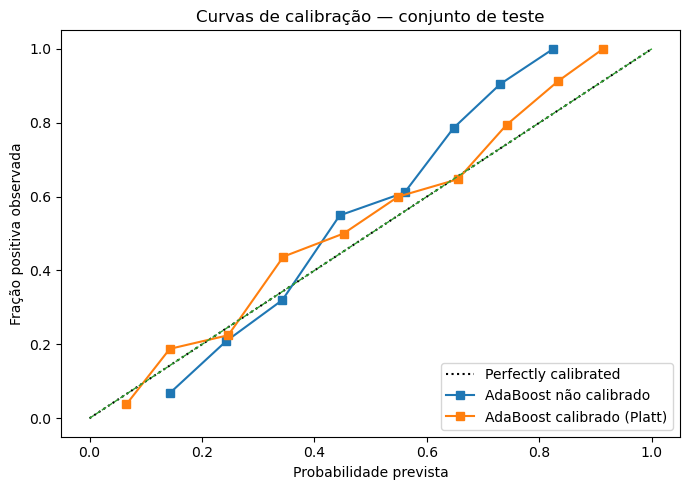

Não calibrado  | Brier: 0.130184 | Log-loss: 0.420338 | AUROC: 0.8423
Calibrado (Platt) | Brier: 0.123816 | Log-loss: 0.394387 | AUROC: 0.8489


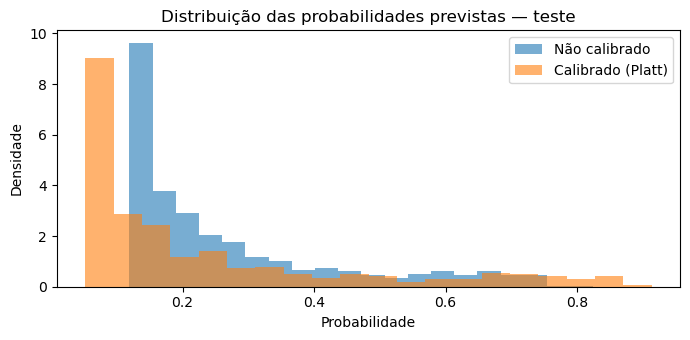

Brier Score do Modelo não calibrado de ADABOOST: 0.1302
P-value Spiegelhalter Modelo Adaboost sem calibração: 0.0000



Brier Score do Modelo calibrado de ADABOOST: 0.1238
P-value Spiegelhalter Modelo Adaboost com calibração: 0.6350





In [30]:
# Curva de calibração

from sklearn.calibration import CalibrationDisplay
from sklearn.metrics import brier_score_loss

adaboost_best_iter.fit(X_train, y_train)

# Probabilidades no teste
probs_unc = adaboost_best_iter.predict_proba(X_test)[:, 1]   # não calibrado
probs_cal = platt_cv.predict_proba(X_test)[:, 1]             # calibrado (Platt)

# Curvas de calibração (reliability diagram)
fig, ax = plt.subplots(figsize=(7,5))
CalibrationDisplay.from_estimator(
    adaboost_best_iter, X_test, y_test,
    n_bins=10, strategy="uniform",
    name="AdaBoost não calibrado", ax=ax
)
CalibrationDisplay.from_estimator(
    platt_cv, X_test, y_test,
    n_bins=10, strategy="uniform",
    name="AdaBoost calibrado (Platt)", ax=ax
)
ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1)  # linha de perfeita calibração
ax.set_title("Curvas de calibração — conjunto de teste")
ax.set_xlabel("Probabilidade prevista")
ax.set_ylabel("Fração positiva observada")
plt.tight_layout()
plt.show()

# Métricas para comparação (quanto menor, melhor em Brier/Log-loss)
print("Não calibrado  | Brier:", f"{brier_score_loss(y_test, probs_unc):.6f}",
      "| Log-loss:", f"{log_loss(y_test, probs_unc):.6f}",
      "| AUROC:", f"{roc_auc_score(y_test, probs_unc):.4f}")

print("Calibrado (Platt) | Brier:", f"{brier_score_loss(y_test, probs_cal):.6f}",
      "| Log-loss:", f"{log_loss(y_test, probs_cal):.6f}",
      "| AUROC:", f"{roc_auc_score(y_test, probs_cal):.4f}")

# Histograma das probabilidades
fig, ax = plt.subplots(figsize=(7,3.5))
ax.hist(probs_unc, bins=20, alpha=0.6, density=True, label="Não calibrado")
ax.hist(probs_cal, bins=20, alpha=0.6, density=True, label="Calibrado (Platt)")
ax.set_title("Distribuição das probabilidades previstas — teste")
ax.set_xlabel("Probabilidade")
ax.set_ylabel("Densidade")
ax.legend()
plt.tight_layout()
plt.show()

# Teste de Spiegelhalter (modelo não calibrado)

from scipy.stats import norm
from sklearn.metrics import brier_score_loss

# Calculando o Brier Score para o modelo
bs = brier_score_loss(y_test, probs_unc)
print(f'Brier Score do Modelo não calibrado de ADABOOST: {bs:.4f}')

# Estatística do teste
EBS = (probs_unc*(1-probs_unc)).sum()/len(probs_unc)
DPBS = np.sqrt(((1-2*probs_unc)**2*probs_unc*(1-probs_unc)).sum())/len(probs_unc)
z = (bs-EBS)/DPBS
pval=2*norm.cdf(-abs(z))
print(f"P-value Spiegelhalter Modelo Adaboost sem calibração: {pval:.4f}")
print("\n\n")

# Teste de Spiegelhalter (modelo calibrado)

# Calculando o Brier Score para o modelo calibrado
bs_cal = brier_score_loss(y_test, probs_cal)
print(f'Brier Score do Modelo calibrado de ADABOOST: {bs_cal:.4f}')

# Estatística do teste
EBS_cal = (probs_cal*(1-probs_cal)).sum()/len(probs_cal)
DPBS_cal = np.sqrt(((1-2*probs_cal)**2*probs_cal*(1-probs_cal)).sum())/len(probs_cal)
z_cal = (bs_cal - EBS_cal)/DPBS_cal
pval_cal = 2*norm.cdf(-abs(z_cal))
print(f"P-value Spiegelhalter Modelo Adaboost com calibração: {pval_cal:.4f}")
print("\n\n")

Acurácia (teste): 82.88%
AUROC (teste): 0.8489
Log-loss (teste): 0.394387


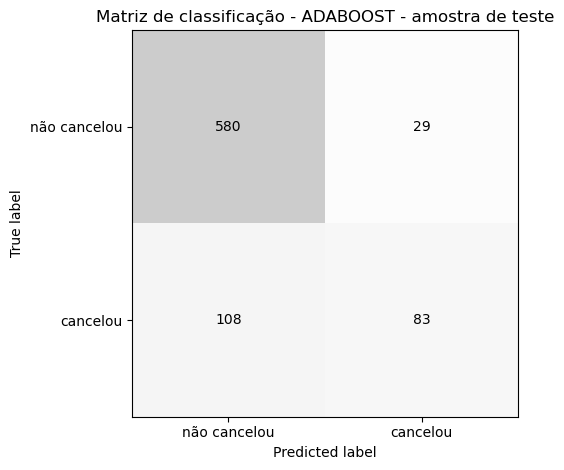

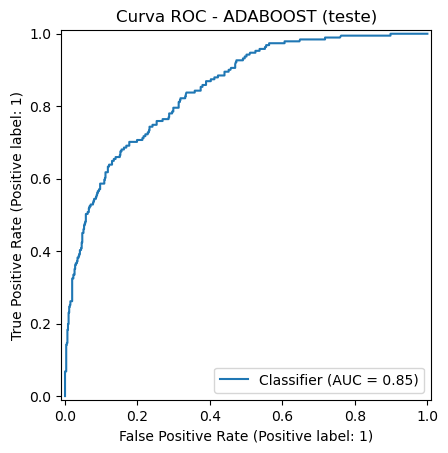

In [31]:
# Avaliação na base de teste (acurácia, AUROC e matriz de classificação)

probs_test_cal = platt_cv.predict_proba(X_test)[:, 1]

# Classificar
preds_test_ada_cal = platt_cv.predict(X_test)

# Avaliar desempenho
acc_cal   = accuracy_score(y_test, preds_test_ada_cal)
auroc_cal = roc_auc_score(y_test, probs_test_cal)
ll_cal    = log_loss(y_test, probs_test_cal)

print(f"Acurácia (teste): {acc_cal:.2%}")
print(f"AUROC (teste): {auroc_cal:.4f}")
print(f"Log-loss (teste): {ll_cal:.6f}")

# Exibir resultados
matriz_cal = confusion_matrix(y_test, preds_test_ada_cal)

light_greys = LinearSegmentedColormap.from_list(
    "light_greys", ["#FFFFFF", "#F2F2F2", "#E5E5E5", "#D9D9D9", "#CCCCCC"]
)

disp = ConfusionMatrixDisplay(confusion_matrix=matriz_cal,
                              display_labels=["não cancelou", "cancelou"])

disp.plot(cmap=light_greys, colorbar=False,
          im_kw={"vmin": 0, "vmax": matriz_cal.max()})
for t in disp.text_.ravel():
    t.set_color("black")

plt.title(f"Matriz de classificação - ADABOOST - amostra de teste")
plt.tight_layout()
plt.show()

# Gráfico: Curva ROC
RocCurveDisplay.from_predictions(y_test, probs_test_cal)
plt.title("Curva ROC - ADABOOST (teste)")
plt.show()

**Capítulo 7**  
**7.9 Aplicação de Gradient Boosting para classificação**<br>
**Base TECAL.xlsx**

In [33]:
from sklearn.ensemble import GradientBoostingClassifier   # algoritmo de GBM

In [34]:
# Definindo o modelo base de Gradient Boosting
modelo_base = GradientBoostingClassifier(random_state=123)

# Grade de hiperparâmetros a ser testada
param_grid = {
    'n_estimators': [500, 1000],          # número de árvores; quanto mais árvores, mais capacidade o modelo tem (mas overfit tende a aumentar)
    'learning_rate': [0.01, 0.05],        # taxa de aprendizado; multiplica o efeito de cada árvore adicionada (menor = mais robusto, mais lento, exije mais árvores)
    'max_depth': [3, 8],                  # profundidade máxima das árvores
    'min_samples_split': [2, 5],          # mínimo de observações para split
    'min_samples_leaf': [1, 3],           # mínimo de observações em folhas
    'subsample': [0.8, 1.0],              # fração da amostra usada em cada árvore
    'max_features': ['sqrt']              # número de variáveis consideradas por split
}

# Configurando o GridSearch com validação cruzada estratificada (5-fold)
grid = GridSearchCV(
    estimator=modelo_base,
    param_grid=param_grid,
    scoring='neg_log_loss',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=123),
    n_jobs=-1,
    verbose=1
)

# Ajustar o modelo com a base de treino
grid.fit(X_train, y_train)

# Exibir os melhores hiperparâmetros e log-loss em CV
print("Melhores hiperparâmetros encontrados:")
print(grid.best_params_)
print(f"Log-loss médio em validação cruzada: {-grid.best_score_:.6f}")

# Construir tabela com os resultados
resultados_grid_gbm = pd.DataFrame(grid.cv_results_)
resultados_grid_gbm['log_loss_cv'] = -resultados_grid_gbm['mean_test_score']
tabela_resultados_gbm = resultados_grid_gbm[['params', 'log_loss_cv', 'rank_test_score', 'mean_fit_time']] \
                                    .sort_values('log_loss_cv', ascending=True)

print("\nTop 5 combinações de hiperparâmetros:")
display(tabela_resultados_gbm.head())

Fitting 5 folds for each of 64 candidates, totalling 320 fits
Melhores hiperparâmetros encontrados:
{'learning_rate': 0.01, 'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500, 'subsample': 0.8}
Log-loss médio em validação cruzada: 0.398529

Top 5 combinações de hiperparâmetros:


,params,log_loss_cv,rank_test_score,mean_fit_time
0,"{'learning_rate': 0.01, 'max_depth': 3, 'max_f...",0.398529,1,4.621653
12,"{'learning_rate': 0.01, 'max_depth': 3, 'max_f...",0.398674,2,5.169373
8,"{'learning_rate': 0.01, 'max_depth': 3, 'max_f...",0.398674,2,4.904628
4,"{'learning_rate': 0.01, 'max_depth': 3, 'max_f...",0.398827,4,4.912030
5,"{'learning_rate': 0.01, 'max_depth': 3, 'max_f...",0.401401,5,4.694389


Top 10 variáveis mais importantes no modelo:


,Variável,Importância
4,fatura,0.292653
2,temp_cli,0.238032
6,local_B,0.160459
0,idade,0.088964
3,renda,0.063630
8,local_D,0.052085
7,local_C,0.043750
5,temp_rsd,0.042373
1,linhas,0.009120
10,debaut_sim,0.004552


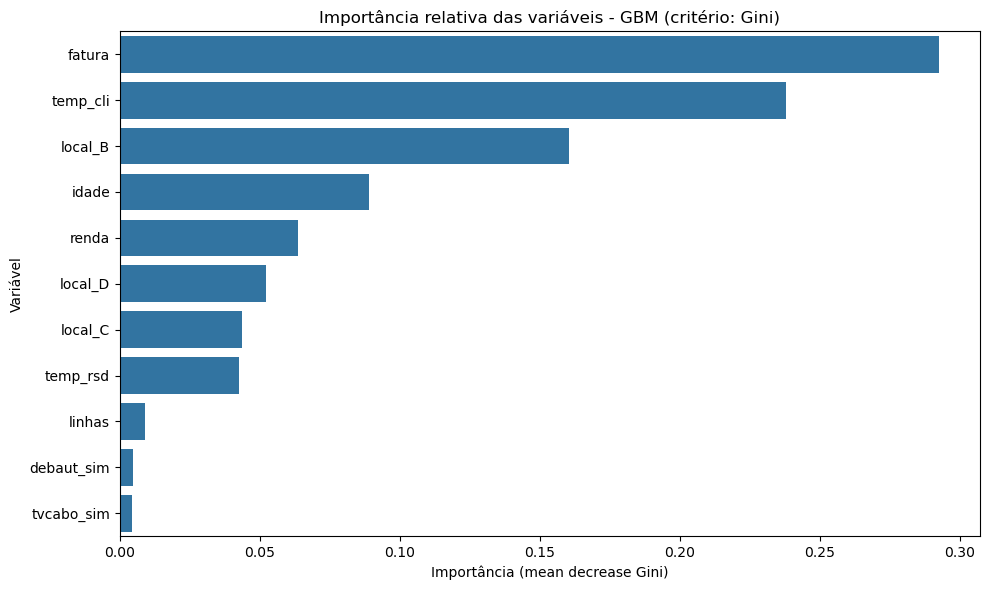

,Variável,MDA (Δ Acurácia média),Desvio-padrão
4,fatura,0.085167,0.006788
2,temp_cli,0.056306,0.007296
6,local_B,0.049556,0.005527
8,local_D,0.018417,0.003143
0,idade,0.015722,0.004109
7,local_C,0.007806,0.002734
5,temp_rsd,0.006972,0.002568
3,renda,0.005639,0.002632
1,linhas,0.002667,0.001384
9,tvcabo_sim,0.002139,0.001576


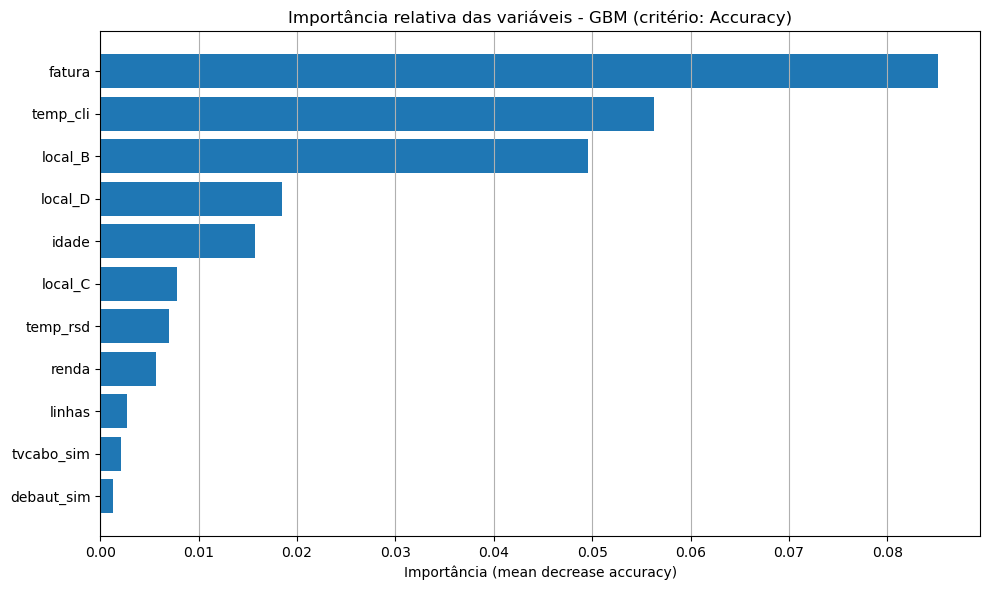

In [35]:
# Cálculo e visualização da importância relativa das variáveis

modelo_final_gbm = grid.best_estimator_

importancias = modelo_final_gbm.feature_importances_

df_importancia = pd.DataFrame({
    'Variável': X_train.columns,
    'Importância': importancias
}).sort_values(by='Importância', ascending=False)

# Visualizar os 10 mais importantes
print("Top 10 variáveis mais importantes no modelo:")
display(df_importancia.head(10))

# Gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(data=df_importancia.head(15), x='Importância', y='Variável')
plt.title('Importância relativa das variáveis - GBM (critério: Gini)')
plt.xlabel('Importância (mean decrease Gini)')
plt.ylabel('Variável')
plt.tight_layout()
plt.show()

perm = permutation_importance(
    modelo_final_gbm, X_train, y_train,
    scoring="accuracy", n_repeats=30,
    random_state=123, n_jobs=-1
)

mda_df = (pd.DataFrame({
    "Variável": X_train.columns,
    "MDA (Δ Acurácia média)": perm.importances_mean,
    "Desvio-padrão": perm.importances_std
})
.sort_values("MDA (Δ Acurácia média)", ascending=False))

display(mda_df.head(15))

topk = 15
mda_plot = mda_df.nlargest(topk, "MDA (Δ Acurácia média)")

plt.figure(figsize=(10, 6))
plt.barh(mda_plot["Variável"], mda_plot["MDA (Δ Acurácia média)"])
plt.xlabel("Importância (mean decrease accuracy)")
plt.title("Importância relativa das variáveis - GBM (critério: Accuracy)")
plt.gca().invert_yaxis()
plt.grid(axis="x")
plt.tight_layout()
plt.show()

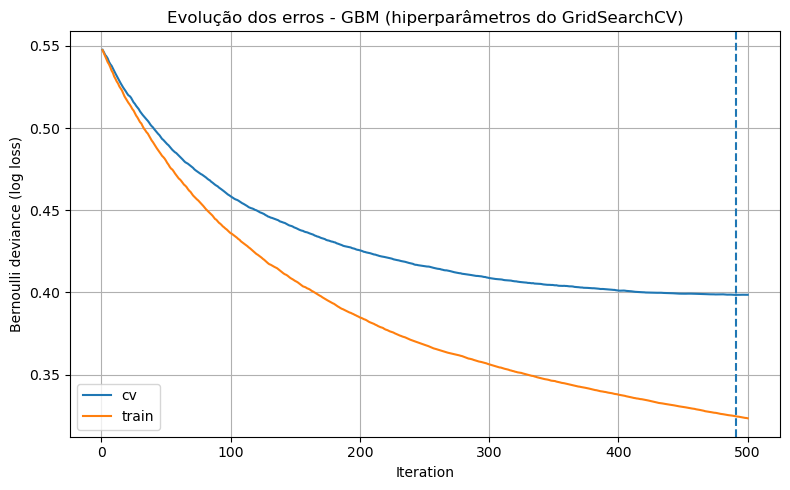

Melhor iteração (menor deviance em CV): 491 de 500


In [52]:
# Evolução dos erros - GBM: train vs. CV 

best = grid.best_params_.copy()

N_EST = best.get('n_estimators', 100)
best['n_estimators'] = N_EST
best.setdefault('random_state', 123)

# Curva de treino
gb_full = GradientBoostingClassifier(**best)
gb_full.fit(X_train, y_train)

# Iterações 1..N_EST (log-loss sobre probas parciais)
train_deviance = np.array([
    log_loss(y_train, proba[:, 1])
    for proba in gb_full.staged_predict_proba(X_train)
])

# Curva de CV (k-fold)
k = 5
cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=123)
cv_deviance = np.zeros(N_EST, dtype=float)

for tr_idx, va_idx in cv.split(X_train, y_train):
    X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
    y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]

    gb = GradientBoostingClassifier(**best)
    gb.fit(X_tr, y_tr)

    # Iterações 1..N_EST
    for i, proba in enumerate(gb.staged_predict_proba(X_va)):
        cv_deviance[i] += log_loss(y_va, proba[:, 1])

cv_deviance /= k

# Melhor iteração
best_iter = int(np.argmin(cv_deviance) + 1)

# Plot
iters = np.arange(1, N_EST + 1)

plt.figure(figsize=(8, 5))
plt.plot(iters, cv_deviance, label="cv")
plt.plot(iters, train_deviance, label="train")
plt.axvline(best_iter, linestyle="--")
plt.xlabel("Iteration")
plt.ylabel("Bernoulli deviance (log loss)")
plt.title("Evolução dos erros - GBM (hiperparâmetros do GridSearchCV)")
plt.legend(loc="best")
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Melhor iteração (menor deviance em CV): {best_iter} de {N_EST}")

In [ ]:
# Reajustando o modelo com {best_iter} iterações:

best = grid.best_params_.copy()
best['n_estimators'] = best_iter

best.setdefault('random_state', 123)
best['n_iter_no_change'] = None

# Modelo final com {best_iter} árvores
gb_best_iter = GradientBoostingClassifier(**best)
gb_best_iter.fit(X_train, y_train)

In [ ]:
# Calibração do modelo (usando cross-validation)

# GBM com os hiperparâmetros escolhidos
base_gbm = gb_best_iter

# Calibração com Platt (sigmoid) via CV
platt_cv_gbm = CalibratedClassifierCV(estimator=base_gbm, method="sigmoid", cv=5)
platt_cv_gbm.fit(X_train, y_train)

# Probabilidades calibradas no teste
probs_test_cal_gbm = platt_cv_gbm.predict_proba(X_test)[:, 1]
print("AUROC (teste):", roc_auc_score(y_test, probs_test_cal_gbm))
print("Log-loss (teste):", log_loss(y_test, probs_test_cal_gbm))

In [ ]:
# Curva de calibração

gb_best_iter.fit(X_train, y_train)
platt_cv_gbm.fit(X_train, y_train)

# Probabilidades no teste
probs_unc_gbm = gb_best_iter.predict_proba(X_test)[:, 1]   # não calibrado
probs_cal_gbm = platt_cv_gbm.predict_proba(X_test)[:, 1]   # calibrado (Platt)

# Curvas de calibração (reliability diagram)
fig, ax = plt.subplots(figsize=(7,5))
CalibrationDisplay.from_estimator(
    gb_best_iter, X_test, y_test,
    n_bins=10, strategy="uniform",
    name="GBM não calibrado", ax=ax
)
CalibrationDisplay.from_estimator(
    platt_cv_gbm, X_test, y_test,
    n_bins=10, strategy="uniform",
    name="GBM calibrado (Platt)", ax=ax
)
ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1)  # linha de perfeita calibração
ax.set_title("Curvas de calibração — conjunto de teste")
ax.set_xlabel("Probabilidade prevista")
ax.set_ylabel("Fração positiva observada")
plt.tight_layout()
plt.show()

# Métricas para comparação (quanto menor, melhor em Brier/Log-loss)
print("Não calibrado  | Brier:", f"{brier_score_loss(y_test, probs_unc_gbm):.6f}",
      "| Log-loss:", f"{log_loss(y_test, probs_unc_gbm):.6f}",
      "| AUROC:", f"{roc_auc_score(y_test, probs_unc_gbm):.4f}")

print("Calibrado (Platt) | Brier:", f"{brier_score_loss(y_test, probs_cal_gbm):.6f}",
      "| Log-loss:", f"{log_loss(y_test, probs_cal_gbm):.6f}",
      "| AUROC:", f"{roc_auc_score(y_test, probs_cal_gbm):.4f}")

# Teste de Spiegelhalter (modelo não calibrado)

from scipy.stats import norm
from sklearn.metrics import brier_score_loss

# Calculando o Brier Score para o modelo
bs = brier_score_loss(y_test, probs_unc_gbm)
print(f'Brier Score do Modelo não calibrado de GBM: {bs:.4f}')

# Estatística do teste
EBS = (probs_unc_gbm*(1-probs_unc_gbm)).sum()/len(probs_unc_gbm)
DPBS = np.sqrt(((1-2*probs_unc_gbm)**2*probs_unc_gbm*(1-probs_unc_gbm)).sum())/len(probs_unc_gbm)
z = (bs-EBS)/DPBS
pval=2*norm.cdf(-abs(z))
print(f"P-value Spiegelhalter Modelo GBM sem calibração: {pval:.4f}")
print("\n\n")

# Teste de Spiegelhalter (modelo calibrado)

# Calculando o Brier Score para o modelo calibrado
bs_cal = brier_score_loss(y_test, probs_cal_gbm)
print(f'Brier Score do Modelo calibrado de GBM: {bs_cal:.4f}')

# Estatística do teste
EBS_cal = (probs_cal_gbm*(1-probs_cal_gbm)).sum()/len(probs_cal_gbm)
DPBS_cal = np.sqrt(((1-2*probs_cal_gbm)**2*probs_cal_gbm*(1-probs_cal_gbm)).sum())/len(probs_cal_gbm)
z_cal = (bs_cal - EBS_cal)/DPBS_cal
pval_cal = 2*norm.cdf(-abs(z_cal))
print(f"P-value Spiegelhalter Modelo GBM com calibração: {pval_cal:.4f}")
print("\n\n")

In [ ]:
# Avaliação na base de teste (acurácia, AUROC e matriz de classificação)

# Obter as probabilidades previstas na base de teste
probs_test_gbm = platt_cv_gbm.predict_proba(X_test)[:, 1]

# Classificar
preds_test_gbm = platt_cv_gbm.predict(X_test)

# Avaliar desempenho
cm_gbm = confusion_matrix(y_test, preds_test_gbm)
acc_gbm = accuracy_score(y_test, preds_test_gbm)
auroc_gbm = roc_auc_score(y_test, probs_test_gbm)
ll_gbm = log_loss(y_test, probs_test_gbm)

# Exibir resultados
light_greys = LinearSegmentedColormap.from_list(
    "light_greys", ["#FFFFFF", "#F2F2F2", "#E5E5E5", "#D9D9D9", "#CCCCCC"]
)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_gbm,
                              display_labels=["não cancelou", "cancelou"])

disp.plot(cmap=light_greys, colorbar=False,
          im_kw={"vmin": 0, "vmax": cm_gbm.max()})
for t in disp.text_.ravel():
    t.set_color("black")

plt.title(f"Matriz de classificação - GBM - amostra de teste")
plt.tight_layout()
plt.show()
print("Matriz de classificação (base de teste):")
print(cm_gbm)
print(f"\n Acurácia na base de teste: {acc_gbm:.3%}")
print(f"AUROC na base de teste: {auroc_gbm:.4f}")
print(f"Log-loss (teste): {ll_gbm:.6f}")

# Gráfico: Curva ROC
RocCurveDisplay.from_predictions(y_test, probs_test_gbm)
plt.title("Curva ROC - GBM (teste)")
plt.show()

**Capítulo 7**  
**7.12 Aplicação de XGBoost a um problema de classificação**<br>
**Base TECAL.xlsx**

In [ ]:
# Caso a biblioteca ainda não esteja instalada
!pip install xgboost

In [ ]:
import xgboost as xgb

from xgboost import XGBClassifier, plot_importance

from sklearn.metrics import log_loss

In [ ]:
# Definindo o modelo base de XGBoost
modelo_base = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

# Grade de hiperparâmetros a ser testada
param_grid = {
    'n_estimators': [400, 600, 800],         # número de árvores (iterações de boosting)
    'learning_rate': [0.01, 0.02],           # taxa de aprendizado (menores = mais robustos, mas exigem mais árvores)
    'max_depth': [10, 15],                   # profundidade máxima de cada árvore (maior = mais complexidade)
    'min_child_weight': [1, 5],              # mínimo de observações em uma folha (evita overfitting em folhas pequenas)
    'gamma': [0, 0.1],                       # ganho mínimo para realizar um split
    'subsample': [0.6, 0.7, 0.8],            # fração da amostra usada em cada árvore
    'colsample_bytree': [0.5, 0.7, 0.8],     # fração das variáveis consideradas por árvore
    }

# Configuração do GridSearchCV com validação cruzada estratificada (5-fold)
grid = GridSearchCV(
    estimator=modelo_base,
    param_grid=param_grid,
    scoring='neg_log_loss',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=123),
    n_jobs=-1,
    verbose=1
)

# Ajustar o modelo com a base de treino
grid.fit(X_train, y_train)

# Exibir os melhores hiperparâmetros e log-loss em CV
print("Melhores hiperparâmetros encontrados:")
print(grid.best_params_)
print(f"Log-loss médio em validação cruzada: {-grid.best_score_:.6f}")

# Construir tabela com os resultados
resultados_grid_xgb = pd.DataFrame(grid.cv_results_)
resultados_grid_xgb['log_loss_cv'] = -resultados_grid_xgb['mean_test_score']
tabela_resultados_xgb = resultados_grid_xgb[['params', 'log_loss_cv', 'rank_test_score', 'mean_fit_time']] \
                                    .sort_values('log_loss_cv', ascending=True)

print("\nTop 5 combinações de hiperparâmetros:")
display(tabela_resultados_xgb.head())

In [ ]:
# Visualização da importância relativa das variáveis (XGBoost)

modelo_xgb = grid.best_estimator_

# Gráfico da importância das variáveis usando função do XGBoost
plt.figure(figsize=(10, 6))
plot_importance(modelo_xgb, max_num_features=15, height=0.5, importance_type='weight')
plt.title('Importância das variáveis segundo o modelo XGBoost')
plt.tight_layout()
plt.show()

In [ ]:
# Visualização do efeito de overfitting no XGBoost

# Converter os dados para DMatrix
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# Acessar o booster interno do modelo final
booster = modelo_xgb.get_booster()

# Curvas de log loss
train_loss = []
test_loss = []

# Avaliar a perda a cada número de árvores (iterações)
for i in range(1, modelo_xgb.n_estimators + 1):
    probas_treino = booster.predict(dtrain, iteration_range=(0, i))
    probas_teste = booster.predict(dtest, iteration_range=(0, i))

    loss_treino = log_loss(y_train, probas_treino)
    loss_teste = log_loss(y_test, probas_teste)

    train_loss.append(loss_treino)
    test_loss.append(loss_teste)

# Plotando as curvas
plt.figure(figsize=(10, 6))
plt.plot(train_loss, label='Treino', linewidth=2)
plt.plot(test_loss, label='Teste', linewidth=2)
plt.xlabel('Número de iterações (n_estimators)')
plt.ylabel('Log loss')
plt.title('Evolução da função de perda – Detecção de overfitting no XGBoost')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
min_index = np.argmin(test_loss)
print(f"Melhor número de iterações: {min_index}")
print(f"Log loss mínimo (teste): {test_loss[min_index]:.4f}")

In [ ]:
# Reajustando o modelo XGBoost com o número ótimo de iterações

best_xgb_params = grid.best_params_.copy()

# Atualiza o número de estimadores para o melhor encontrado na análise de overfitting
best_xgb_params['n_estimators'] = min_index

# Modelo final com o número ótimo de árvores
xgb_otimo = XGBClassifier(
    eval_metric='logloss',
    random_state=123,
    **best_xgb_params
)

# Ajusta o modelo nos dados completos de treino
xgb_otimo.fit(X_train, y_train)

print("Modelo XGBoost reajustado com o número ótimo de iterações.")

In [ ]:
# Calibração do modelo (usando cross-validation)

# XGBOOST com os hiperparâmetros escolhidos
base_xgb = xgb_otimo

# Calibração com Platt (sigmoid) via CV
platt_cv_xgb = CalibratedClassifierCV(estimator=base_xgb, method="sigmoid", cv=5)
platt_cv_xgb.fit(X_train, y_train)

# Probabilidades calibradas no teste
probs_test_cal_xgb = platt_cv_xgb.predict_proba(X_test)[:, 1]
print("AUROC (teste):", roc_auc_score(y_test, probs_test_cal_xgb))
print("Log-loss (teste):", log_loss(y_test, probs_test_cal_xgb))

In [ ]:
# Curva de calibração

xgb_otimo.fit(X_train, y_train)
platt_cv_xgb.fit(X_train, y_train)

# Probabilidades no teste
probs_unc_xgb = xgb_otimo.predict_proba(X_test)[:, 1]         # não calibrado
probs_cal_xgb = platt_cv_xgb.predict_proba(X_test)[:, 1]   # calibrado (Platt)

# Curvas de calibração (reliability diagram)
fig, ax = plt.subplots(figsize=(7,5))
CalibrationDisplay.from_estimator(
    xgb_otimo, X_test, y_test,
    n_bins=10, strategy="uniform",
    name="XGBOOST não calibrado", ax=ax
)
CalibrationDisplay.from_estimator(
    platt_cv_xgb, X_test, y_test,
    n_bins=10, strategy="uniform",
    name="XGBOOST calibrado (Platt)", ax=ax
)
ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1)  # linha de perfeita calibração
ax.set_title("Curvas de calibração — conjunto de teste")
ax.set_xlabel("Probabilidade prevista")
ax.set_ylabel("Fração positiva observada")
plt.tight_layout()
plt.show()

# Métricas para comparação (quanto menor, melhor em Brier/Log-loss)
print("Não calibrado  | Brier:", f"{brier_score_loss(y_test, probs_unc_xgb):.6f}",
      "| Log-loss:", f"{log_loss(y_test, probs_unc_xgb):.6f}",
      "| AUROC:", f"{roc_auc_score(y_test, probs_unc_xgb):.4f}")

print("Calibrado (Platt)) | Brier:", f"{brier_score_loss(y_test, probs_cal_xgb):.6f}",
      "| Log-loss:", f"{log_loss(y_test, probs_cal_xgb):.6f}",
      "| AUROC:", f"{roc_auc_score(y_test, probs_cal_xgb):.4f}")

# Teste de Spiegelhalter (modelo não calibrado)

from scipy.stats import norm
from sklearn.metrics import brier_score_loss

# Calculando o Brier Score para o modelo
bs = brier_score_loss(y_test, probs_unc_xgb)
print(f'Brier Score do Modelo não calibrado de XGBoost: {bs:.4f}')

# Estatística do teste
EBS = (probs_unc_xgb*(1-probs_unc_xgb)).sum()/len(probs_unc_xgb)
DPBS = np.sqrt(((1-2*probs_unc_xgb)**2*probs_unc_xgb*(1-probs_unc_xgb)).sum())/len(probs_unc_xgb)
z = (bs-EBS)/DPBS
pval=2*norm.cdf(-abs(z))
print(f"P-value Spiegelhalter Modelo XGBoost sem calibração: {pval:.4f}")
print("\n\n")

# Teste de Spiegelhalter (modelo calibrado)

# Calculando o Brier Score para o modelo calibrado
bs_cal = brier_score_loss(y_test, probs_cal_xgb)
print(f'Brier Score do Modelo calibrado de XGBoost: {bs_cal:.4f}')

# Estatística do teste
EBS_cal = (probs_cal_xgb*(1-probs_cal_xgb)).sum()/len(probs_cal_xgb)
DPBS_cal = np.sqrt(((1-2*probs_cal_xgb)**2*probs_cal_xgb*(1-probs_cal_xgb)).sum())/len(probs_cal_xgb)
z_cal = (bs_cal - EBS_cal)/DPBS_cal
pval_cal = 2*norm.cdf(-abs(z_cal))
print(f"P-value Spiegelhalter Modelo XGBoost com calibração: {pval_cal:.4f}")
print("\n\n")

In [ ]:
# Avaliação na base de teste (acurácia, AUROC e matriz de classificação)

# Obter as probabilidades previstas na base de teste
probs_test_xgb = xgb_otimo.predict_proba(X_test)[:, 1]

# Classificar
preds_test_xgb = xgb_otimo.predict(X_test)

# Avaliar desempenho
cm_xgb = confusion_matrix(y_test, preds_test_xgb)
acc_xgb = accuracy_score(y_test, preds_test_xgb)
auroc_xgb = roc_auc_score(y_test, probs_test_xgb)
ll_xgb = log_loss(y_test, probs_test_xgb)

# Exibir resultados
light_greys = LinearSegmentedColormap.from_list(
    "light_greys", ["#FFFFFF", "#F2F2F2", "#E5E5E5", "#D9D9D9", "#CCCCCC"]
)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb,
                              display_labels=["não cancelou", "cancelou"])

disp.plot(cmap=light_greys, colorbar=False,
          im_kw={"vmin": 0, "vmax": cm_xgb.max()})
for t in disp.text_.ravel():
    t.set_color("black")

plt.title(f"Matriz de classificação - XGBOOST - amostra de teste")
plt.tight_layout()
plt.show()
print("Matriz de classificação (base de teste):")
print(cm_xgb)
print(f"\n Acurácia na base de teste: {acc_xgb:.3%}")
print(f"AUROC na base de teste: {auroc_xgb:.4f}")
print(f"Log-loss (teste): {ll_xgb:.6f}")

# Gráfico: Curva ROC
RocCurveDisplay.from_predictions(y_test, probs_test_xgb)
plt.title("Curva ROC - XGBOOST (teste)")
plt.show()